In [ ]:
# Predicting Boston Property Values Using Machine Learning

## Introduction
'''
This project aims to predict property assessed values in Boston using public assessment data.

We treat the problem as a regression task where property characteristics such as area, number of rooms, bathrooms, fireplaces, parking, and year built are used to predict the total property value.

We evaluate three approaches:
- Baseline mean predictor
- Linear Regression
- Random Forest Regressor

The goal is to compare model performance using RMSE and R² and understand which property features are most important for valuation.'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
## Load Dataset
'''
The dataset used in this project is the FY2026 Boston Property Assessment dataset obtained from Analyze Boston.'''

In [2]:
df = pd.read_csv(
    "../data/fy2026-property-assessment-data_12_23_2025.csv",
    low_memory=False
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (184552, 66)


,PID,CM_ID,GIS_ID,ST_NUM,ST_NUM2,ST_NAME,UNIT_NUM,CITY,ZIP_CODE,BLDG_SEQ,...,KITCHEN_STYLE2,KITCHEN_STYLE3,HEAT_TYPE,HEAT_SYSTEM,AC_TYPE,FIREPLACES,ORIENTATION,NUM_PARKING,PROP_VIEW,CORNER_UNIT
0,100001000,NaN,100001000,195.0,NaN,Lexington ST,NaN,EAST BOSTON,2128.0,1,...,S - Semi-Modern,S - Semi-Modern,W - Ht Water/Steam,NaN,N - None,0.0,NaN,3.0,A - Average,NaN
1,100002000,NaN,100002000,197.0,NaN,Lexington ST,NaN,EAST BOSTON,2128.0,1,...,M - Modern,M - Modern,F - Forced Hot Air,NaN,C - Central AC,0.0,NaN,0.0,A - Average,NaN
2,100003000,NaN,100003000,199.0,NaN,Lexington ST,NaN,EAST BOSTON,2128.0,1,...,S - Semi-Modern,S - Semi-Modern,S - Space Heat,NaN,N - None,0.0,NaN,0.0,A - Average,NaN
3,100004000,NaN,100004000,201.0,NaN,Lexington ST,NaN,EAST BOSTON,2128.0,1,...,S - Semi-Modern,S - Semi-Modern,W - Ht Water/Steam,NaN,N - None,0.0,NaN,0.0,A - Average,NaN
4,100005000,NaN,100005000,203.0,NaN,Lexington ST,NaN,EAST BOSTON,2128.0,1,...,N - No Remodeling,S - Semi-Modern,W - Ht Water/Steam,NaN,N - None,0.0,NaN,0.0,A - Average,NaN


In [ ]:
'''## Data Cleaning

The original `TOTAL_VALUE` column is stored as text and contains commas.  
It must be converted into numeric format before analysis and modeling'''

In [3]:
# clean target column 
df["TOTAL_VALUE_CLEAN"] = (
    df["TOTAL_VALUE"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["TOTAL_VALUE_CLEAN"] = pd.to_numeric(df["TOTAL_VALUE_CLEAN"], errors="coerce")

# Remove invalid or zero values
df = df[df["TOTAL_VALUE_CLEAN"] > 0]

print(df["TOTAL_VALUE_CLEAN"].describe())

count    1.734060e+05
mean     1.644613e+06
std      1.417155e+07
min      1.000000e+02
25%      4.638000e+05
50%      7.030000e+05
75%      1.035400e+06
max      2.448193e+09
Name: TOTAL_VALUE_CLEAN, dtype: float64


In [ ]:
'''## Basic Dataset Information

We inspect the dataset structure and identify the target variable and available predictors.'''

In [4]:
# Columns and dtypes 
print(df.columns.tolist())
print(df.dtypes)

['PID', 'CM_ID', 'GIS_ID', 'ST_NUM', 'ST_NUM2', 'ST_NAME', 'UNIT_NUM', 'CITY', 'ZIP_CODE', 'BLDG_SEQ', 'NUM_BLDGS', 'LUC', 'LU', 'LU_DESC', 'BLDG_TYPE', 'OWN_OCC', 'OWNER', 'MAIL_ADDRESSEE', 'MAIL_STREET_ADDRESS', 'MAIL_CITY', 'MAIL_STATE', 'MAIL_ZIP_CODE', 'RES_FLOOR', 'CD_FLOOR', 'RES_UNITS', 'COM_UNITS', 'RC_UNITS', 'LAND_SF', 'GROSS_AREA', 'LIVING_AREA', 'LAND_VALUE', 'BLDG_VALUE', 'SFYI_VALUE', 'TOTAL_VALUE', ' GROSS_TAX ', 'YR_BUILT', 'YR_REMODEL', 'STRUCTURE_CLASS', 'ROOF_STRUCTURE', 'ROOF_COVER', 'INT_WALL', 'EXT_FNISHED', 'INT_COND', 'EXT_COND', 'OVERALL_COND', 'BED_RMS', 'FULL_BTH', 'HLF_BTH', 'KITCHENS', 'TT_RMS', 'BDRM_COND', 'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_TYPE', 'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3', 'HEAT_TYPE', 'HEAT_SYSTEM', 'AC_TYPE', 'FIREPLACES', 'ORIENTATION', 'NUM_PARKING', 'PROP_VIEW', 'CORNER_UNIT', 'TOTAL_VALUE_CLEAN']
PID                    int64
CM_ID                float64
GIS_ID                 int64
ST_NUM           

In [ ]:
'''## Exploratory Data Analysis

Property values are often highly skewed because a small number of properties are extremely expensive.  
We examine the distribution of the target variable using raw, filtered, and log-transformed visualizations.'''

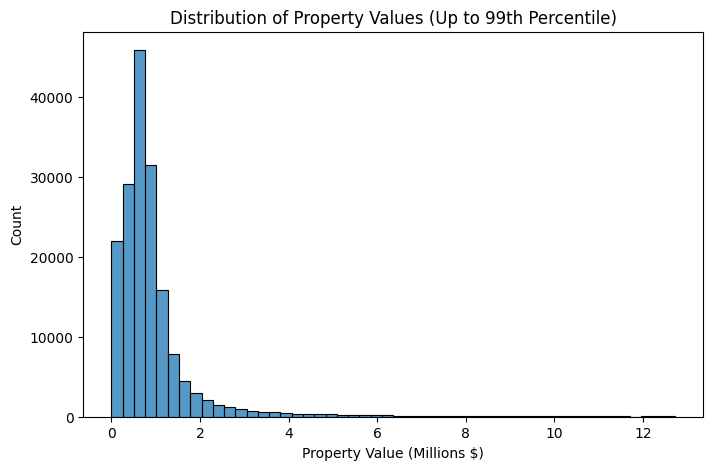

In [5]:
#Histogram with 99th percentile filter
upper_99 = df["TOTAL_VALUE_CLEAN"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(
    df[df["TOTAL_VALUE_CLEAN"] <= upper_99]["TOTAL_VALUE_CLEAN"] / 1e6,
    bins=50
)
plt.title("Distribution of Property Values (Up to 99th Percentile)")
plt.xlabel("Property Value (Millions $)")
plt.ylabel("Count")
plt.show()

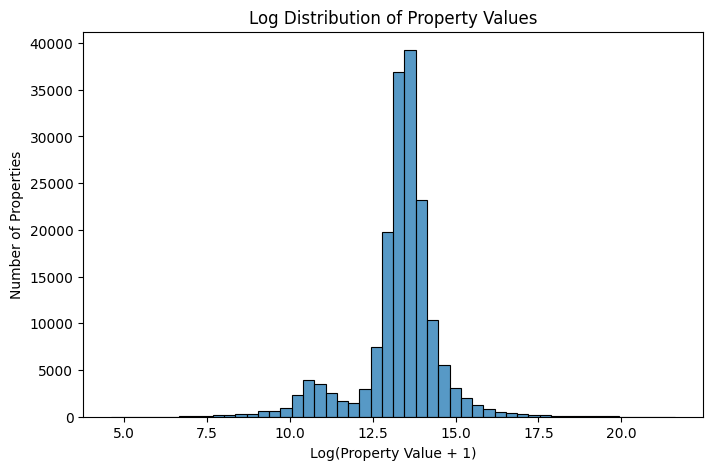

In [6]:
#log Distribution
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df["TOTAL_VALUE_CLEAN"]), bins=50)
plt.title("Log Distribution of Property Values")
plt.xlabel("Log(Property Value + 1)")
plt.ylabel("Number of Properties")
plt.show()

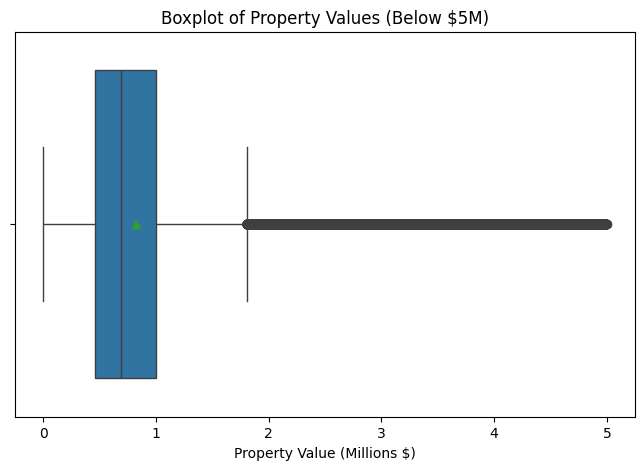

In [7]:
#Boxplot below 5M
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df[df["TOTAL_VALUE_CLEAN"] < 5_000_000]["TOTAL_VALUE_CLEAN"] / 1e6,
    showmeans=True
)
plt.title("Boxplot of Property Values (Below $5M)")
plt.xlabel("Property Value (Millions $)")
plt.show()

In [ ]:
'''## Feature Selection

To avoid data leakage, we do not use valuation columns such as `LAND_VALUE`, `BLDG_VALUE`, `SFYI_VALUE`, or `TOTAL_VALUE` as predictors.

Instead, we use physical and structural property characteristics:
- Land area
- Gross area
- Living area
- Year built
- Bedrooms
- Bathrooms
- Kitchens
- Fireplaces
- Parking'''

In [8]:
# Select features and targets 
features = [
    "LAND_SF",
    "GROSS_AREA",
    "LIVING_AREA",
    "YR_BUILT",
    "BED_RMS",
    "FULL_BTH",
    "HLF_BTH",
    "KITCHENS",
    "FIREPLACES",
    "NUM_PARKING"
]

X = df[features].copy()
y = df["TOTAL_VALUE_CLEAN"].copy()

In [9]:
#Convert features to numeric and drop missing rows 
for col in X.columns:
    X.loc[:, col] = pd.to_numeric(X[col], errors="coerce")

X = X.dropna()
y = y.loc[X.index]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature matrix shape: (40487, 10)
Target shape: (40487,)


,LAND_SF,GROSS_AREA,LIVING_AREA,YR_BUILT,BED_RMS,FULL_BTH,HLF_BTH,KITCHENS,FIREPLACES,NUM_PARKING
12,766.0,766.0,766.0,1900.0,2.0,1.0,0.0,1.0,0.0,0.0
34,791.0,791.0,791.0,1900.0,2.0,1.0,0.0,1.0,0.0,0.0
35,876.0,876.0,876.0,1900.0,2.0,2.0,0.0,1.0,0.0,0.0
127,694.0,694.0,694.0,1905.0,2.0,1.0,0.0,1.0,0.0,0.0
133,852.0,852.0,852.0,1900.0,2.0,1.0,1.0,1.0,0.0,0.0


In [ ]:
'''## Correlation Analysis

A correlation heatmap helps us understand relationships among the selected numeric features.
'''

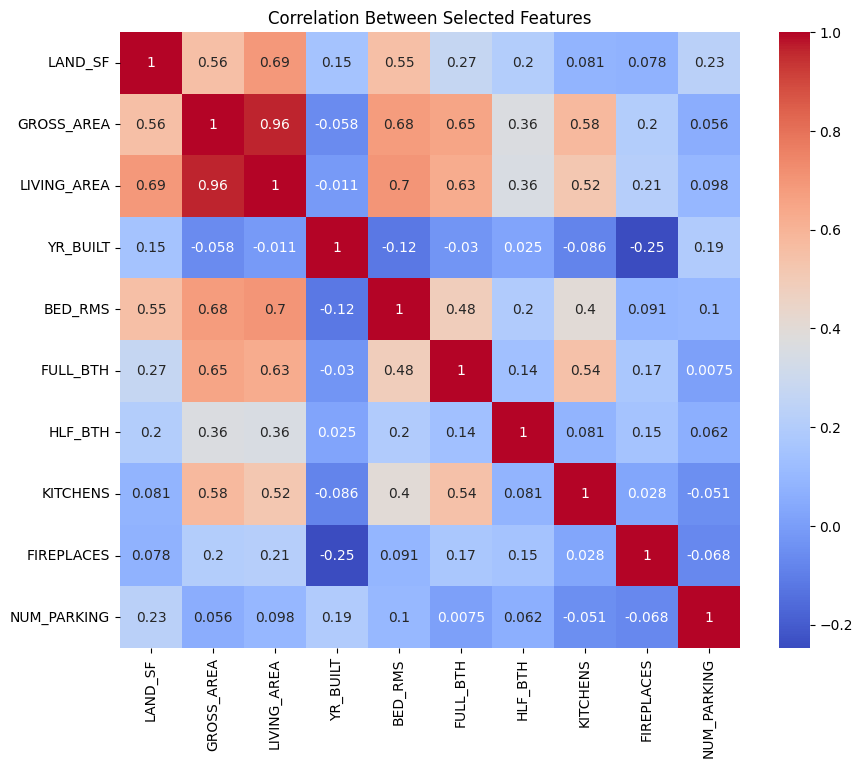

In [10]:
#Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Between Selected Features")
plt.show()

In [ ]:
'''## Baseline Model

As suggested in the project feedback, a trivial mean-predictor baseline is used to anchor RMSE comparisons.

This model predicts the mean property value for all properties.'''

In [11]:
# Baseline RMSE
mean_value = y.mean()
baseline_predictions = np.full(len(y), mean_value)

rmse_baseline = np.sqrt(mean_squared_error(y, baseline_predictions))

print("Baseline RMSE:", rmse_baseline)

rmse_baseline = np.sqrt(mean_squared_error(y, baseline_predictions))

print("Baseline RMSE:", rmse_baseline)

Baseline RMSE: 297435.69255243114
Baseline RMSE: 297435.69255243114


In [ ]:
'''## Train-Test Split

The dataset is divided into training and testing sets so model performance can be evaluated on unseen data.'''

In [12]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (32389, 10)
X_test: (8098, 10)
y_train: (32389,)
y_test: (8098,)


In [ ]:
'''## Linear Regression Model

Linear Regression is used as a simple interpretable baseline machine learning model.'''

In [13]:
# Train and evaluate linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 200170.29448405752
Linear Regression R2: 0.539455196439265


/Users/athulyagopal/boston-property-value-prediction/.venv-1/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/athulyagopal/boston-property-value-prediction/.venv-1/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/athulyagopal/boston-property-value-prediction/.venv-1/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [ ]:
'''## Random Forest Regressor

Random Forest is an ensemble model that can capture nonlinear relationships and feature interactions better than linear regression.'''


In [14]:
#Train and evaluate Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 152761.02642159615
Random Forest R2: 0.7317759190945257


In [ ]:
'''Model Comparison

We compare the baseline model, Linear Regression, and Random Forest using RMSE and R².'''

In [15]:
# Comparison table
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "RMSE": [rmse_baseline, lr_rmse, rf_rmse],
    "R2": [0.0, lr_r2, rf_r2]
})

results

,Model,RMSE,R2
0,Baseline,297435.692552,0.000000
1,Linear Regression,200170.294484,0.539455
2,Random Forest,152761.026422,0.731776


In [ ]:
'''# Actual vs Predicted Values

A scatter plot of actual versus predicted property values helps visualize model performance.'''

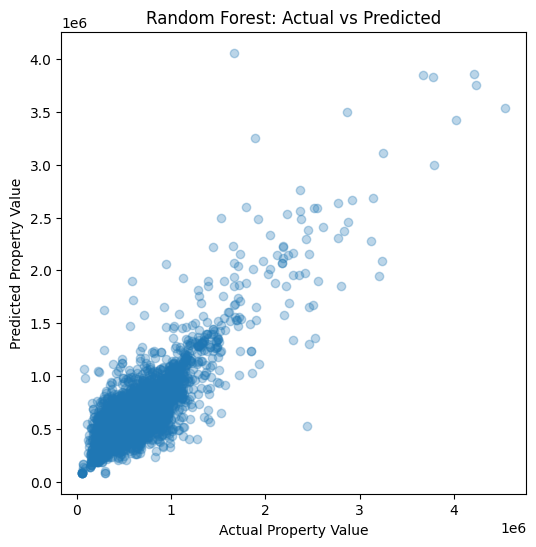

In [16]:
#Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.xlabel("Actual Property Value")
plt.ylabel("Predicted Property Value")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [ ]:
''' Feature Importance

Random Forest provides feature importance scores, which help identify which property characteristics contribute most to valuation.'''

LIVING_AREA    0.472810
YR_BUILT       0.174843
FIREPLACES     0.121297
GROSS_AREA     0.071981
LAND_SF        0.069287
BED_RMS        0.034536
NUM_PARKING    0.021594
HLF_BTH        0.014125
FULL_BTH       0.013789
KITCHENS       0.005737
dtype: float64


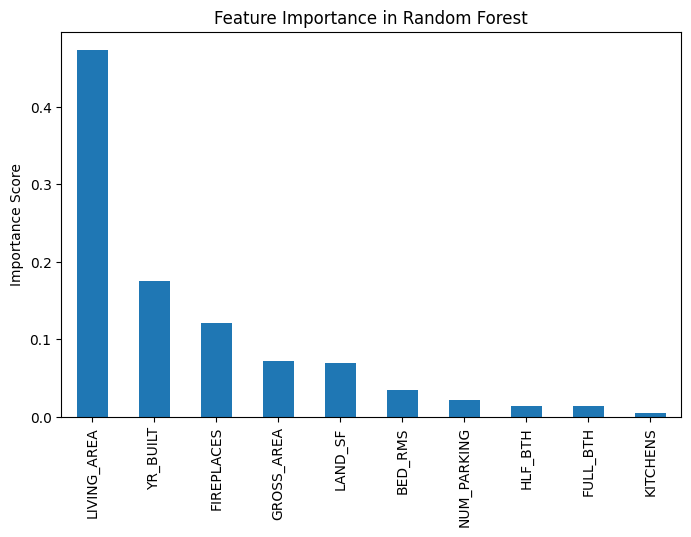

In [17]:
#Feature importance values and plot
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8, 5))
importance.plot(kind="bar")
plt.title("Feature Importance in Random Forest")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
'''## Extreme High-Value Properties

To understand why the target variable is highly skewed, we inspect the most expensive properties in the dataset.'''

In [18]:
# Top 10 Values
print(df["TOTAL_VALUE_CLEAN"].sort_values(ascending=False).head(10))

18756     2448193300
41086     1501144286
41359     1092989100
41095     1070491100
39040      848281700
102920     843434400
27383      678221500
41069      638093900
41049      624438200
79628      621270200
Name: TOTAL_VALUE_CLEAN, dtype: int64


In [ ]:
'''## Conclusion

The baseline mean predictor produced the highest RMSE, confirming that simply predicting the average property value is not sufficient.

Linear Regression significantly improved performance, showing that structural property features are useful predictors of assessed value.

Random Forest achieved the best results with the lowest RMSE, indicating that nonlinear ensemble methods are better suited for this real estate valuation task.

Overall, this project demonstrates that machine learning can effectively estimate Boston property values using structured public assessment data.

In [19]:
#Print Final Summary
print("Final Results")
print("----------------------------")
print("Baseline RMSE:", rmse_baseline)
print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)
print("Linear Regression R2:", lr_r2)
print("Random Forest R2:", rf_r2)

Final Results
----------------------------
Baseline RMSE: 297435.69255243114
Linear Regression RMSE: 200170.29448405752
Random Forest RMSE: 152761.02642159615
Linear Regression R2: 0.539455196439265
Random Forest R2: 0.7317759190945257


In [20]:
#Save results 
results.to_csv("../results/model_results.csv", index=False)